In [1]:
import os
import pandas as pd
from supabase import create_client
from dotenv import load_dotenv

# --- Load environment ---
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

# --- Initialize Supabase client ---
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# --- Pull data from Supabase ---
response = supabase.table("press_releases_clean").select("*").execute()

# --- Convert to DataFrame ---
articles_df = pd.DataFrame(response.data)

# --- Display preview ---
articles_df.head()


,id,title,url,date,scraped_at,content,author,status,updated_at
0,e7148816-b1d5-464b-9dbe-0f9d86e06ec2,Federal Reserve Board approves action by the B...,https://www.federalreserve.gov/newsevents/pres...,2016-12-15,2025-10-23T03:47:45.443933+00:00,The Federal Reserve Board has approved action ...,None,complete,2025-10-23T03:48:35.306345+00:00
1,567f9fb3-1b1d-426d-9a6d-d28f8ba19151,Federal Reserve Board adopts final rule to str...,https://www.federalreserve.gov/newsevents/pres...,2016-12-15,2025-10-23T03:47:45.443937+00:00,The Federal Reserve Board on Thursday adopted ...,None,complete,2025-10-23T03:48:36.525+00:00
2,7eeb9eac-fd66-453c-a117-96b7b25e6558,Federal Reserve issues FOMC statement,https://www.federalreserve.gov/newsevents/pres...,2016-12-14,2025-10-23T03:47:45.443941+00:00,Information received since the Federal Open Ma...,None,complete,2025-10-23T03:48:37.750499+00:00
3,2888ee2f-7137-4874-93fd-25a0f7ea8fb6,Federal Reserve Board and Federal Open Market ...,https://www.federalreserve.gov/newsevents/pres...,2016-12-14,2025-10-23T03:47:45.443946+00:00,The attached table and charts released on Wedn...,None,complete,2025-10-23T03:48:38.96562+00:00
4,f7c174ad-c168-4067-b87d-2cf716b93e9a,Agencies announce determinations on October re...,https://www.federalreserve.gov/newsevents/pres...,2016-12-13,2025-10-23T03:47:45.44395+00:00,Board of Governors of the Federal Reserve Syst...,None,complete,2025-10-23T03:48:40.182538+00:00


In [2]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1000 non-null   object
 1   title       1000 non-null   object
 2   url         1000 non-null   object
 3   date        1000 non-null   object
 4   scraped_at  1000 non-null   object
 5   content     1000 non-null   object
 6   author      4 non-null      object
 7   status      1000 non-null   object
 8   updated_at  1000 non-null   object
dtypes: object(9)
memory usage: 70.4+ KB


In [3]:
# Drop unused columns
articles_df = articles_df.drop(columns=["id", "author"], errors="ignore")

# Confirm structure
articles_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       1000 non-null   object
 1   url         1000 non-null   object
 2   date        1000 non-null   object
 3   scraped_at  1000 non-null   object
 4   content     1000 non-null   object
 5   status      1000 non-null   object
 6   updated_at  1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


In [4]:
articles_df["word_count"] = articles_df["content"].apply(lambda x: len(str(x).split()))
articles_df[["title", "date", "word_count"]].head(5)


,title,date,word_count
0,Federal Reserve Board approves action by the B...,2016-12-15,40
1,Federal Reserve Board adopts final rule to str...,2016-12-15,505
2,Federal Reserve issues FOMC statement,2016-12-14,541
3,Federal Reserve Board and Federal Open Market ...,2016-12-14,58
4,Agencies announce determinations on October re...,2016-12-13,652


In [5]:
# Ensure 'date' is a real datetime column
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")

# Drop any rows where date could not be parsed
articles_df = articles_df[articles_df["date"].notnull()]

# Now safely extract year
articles_df["year"] = articles_df["date"].dt.year


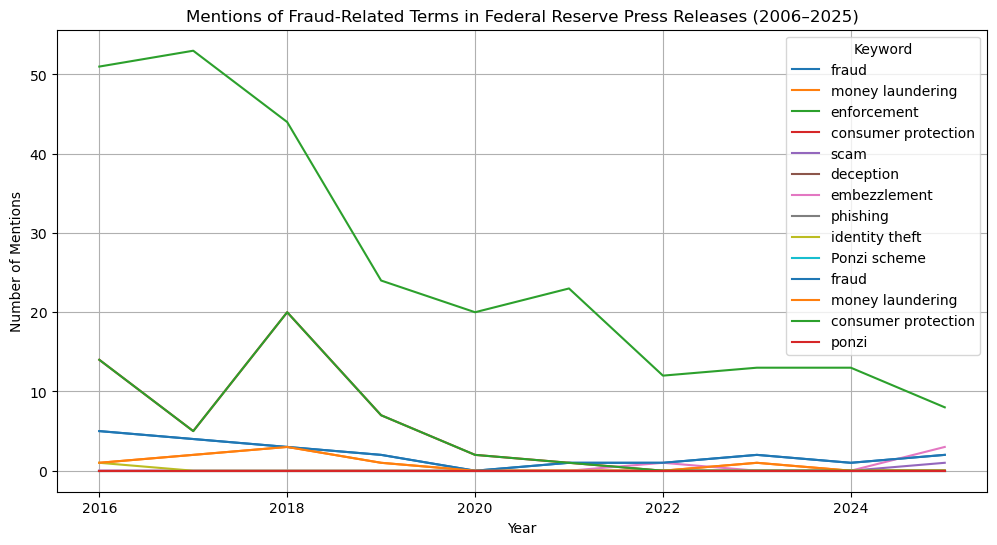

In [6]:
import matplotlib.pyplot as plt

# Make sure dates are datetime and year exists
articles_df["date"] = pd.to_datetime(articles_df["date"], errors="coerce")
articles_df["year"] = articles_df["date"].dt.year

# Combine all text into lowercase for keyword matching
articles_df["content_lower"] = articles_df["content"].fillna("").str.lower()

# Keywords to track
keywords = ["fraud", "money laundering", "enforcement", "consumer protection", "scam", "deception",
            "embezzlement", "phishing", "identity theft", "Ponzi scheme", "fraud", "money laundering",
            "consumer protection", "ponzi"] 

# Count keyword hits per article
for kw in keywords:
    articles_df[kw] = articles_df["content_lower"].str.contains(kw, case=False, na=False)

# Aggregate counts by year
keyword_trends = (
    articles_df.groupby("year")[keywords]
    .sum()
    .reset_index()
)

# Plot the trends
keyword_trends.plot(x="year", figsize=(12,6))
plt.title("Mentions of Fraud-Related Terms in Federal Reserve Press Releases (2006–2025)")
plt.ylabel("Number of Mentions")
plt.xlabel("Year")
plt.legend(title="Keyword")
plt.grid(True)
plt.show()
